Siempre que hay una sola variable para realizar una predicción, no es muy util.

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [4]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [5]:
df = pd.DataFrame(lista_alumnos, columns=["Nombre", "Edad", "Altura"])
df

,Nombre,Edad,Altura
0,Leonardo S,24,1.82
1,Piero T,25,1.71
2,Marta B,35,1.66
3,Silvia P,37,1.63
4,Faro Z,29,1.90
5,Miguel N,27,1.80
6,Alejandro M,28,1.70
7,Cristina M,32,1.60
8,Francisco P,36,1.74
9,Jorge D,45,1.72


Este modelo tiene underfitting. Menos de 1000 registros es dificiil hacer predicciones.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Nombre  21 non-null     object 
 1   Edad    21 non-null     int64  
 2   Altura  21 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 636.0+ bytes


In [7]:
df.describe()

,Edad,Altura
count,21.000000,21.000000
mean,32.095238,1.727143
std,6.081980,0.079003
min,23.000000,1.600000
25%,27.000000,1.660000
50%,32.000000,1.720000
75%,36.000000,1.800000
max,45.000000,1.900000


<Axes: xlabel='Edad', ylabel='Altura'>

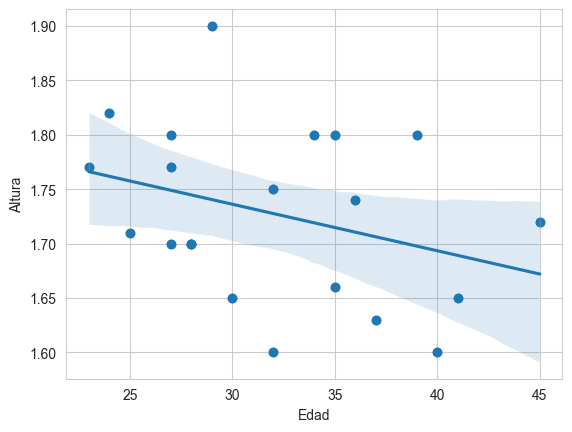

In [15]:
plt.scatter(df["Edad"], df["Altura"])
sns.regplot(data = df, x = "Edad", y = "Altura")

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

La correlación no va a ser muy buena. No es una buena técnica.

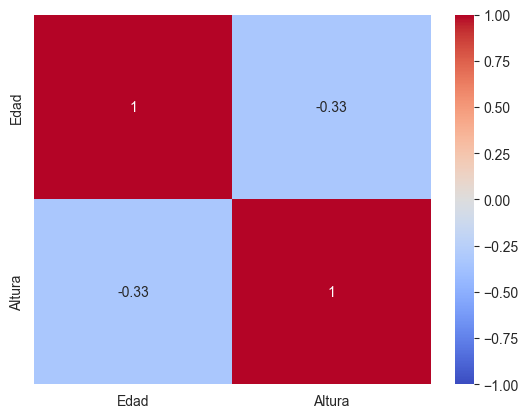

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, cmap='coolwarm');

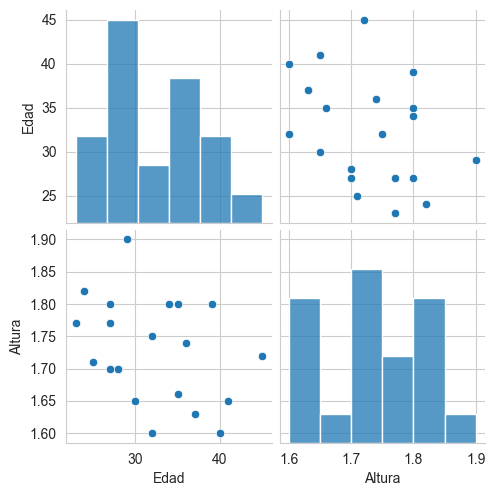

In [49]:
sns.pairplot(df)

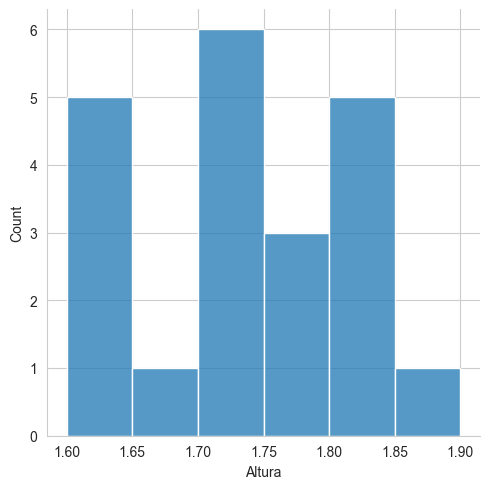

In [27]:
sns.displot(data=df, x="Altura")

### Entrena un modelo de regresión lineal

In [28]:
X = df[["Edad"]]
y = df["Altura"]

In [ ]:
# En datasets muy pequeños, mejor coger menos registros para test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [31]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(16, 1)
(16,)
(5, 1)
(5,)


In [34]:
lm = LinearRegression()
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
pred = lm.predict([[31]])
print(pred)

[1.72297779]


c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [42]:
prediccion = lm.predict(X_test)
print(prediccion)

[1.75347826 1.70990616 1.71862058 1.74912105 1.70119174]


In [45]:
X_test

,Edad
0,24
17,34
15,32
1,25
8,36


In [46]:
valores = X_test
valores["Altura"] = y_test
valores["pred"] = prediccion
valores

,Edad,Altura,pred
0,24,1.82,1.753478
17,34,1.80,1.709906
15,32,1.75,1.718621
1,25,1.71,1.749121
8,36,1.74,1.701192


### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

### MÉTRICAS APLICADAS A LA REGRESIÓN LINEAL

Existen muchas métricas para muchos modelos. Se pueden hacer métricas propias.

MAE: Es la métrica más básica y simple, pero también una de las más claras. El error medio absoluto del conjunto de test calcula, en promedio, cuánto se desvían las predicciones de los valores reales. Se obtiene tomando la media de los valores absolutos de los errores individuales (|y_real − y_predicho|). La unidad del MAE es la misma que la del target.

MSE: Min Square Error. Es lo mismo que lo anterior pero elevado al cuadrado. Evalúa los fallos grandes. Tiene menos tolerancia a los fallos grandes. Interesa un MSE bajo. Aunque tengamos un MAE bajo podemos tener un MSE alto, lo que significa que puede haber muchos valores alejados de la media.

RMSE: es lo mismo que lo anterior pero devolviendo en las unidadades del target. Tambien evalua los errores grandes

MAPE: No toma el MAE directamente, sino que calcula qué porcentaje representa el error absoluto de cada predicción respecto al valor real. Es decir, mide qué porcentaje de error hay dentro del propio valor del elemento (por ejemplo, qué porcentaje del “precio total” representa el error). Luego hace la media de todos esos porcentajes.

Intercepto: Es el valor del target cuando todas las variables independientes son 0. Representa el punto de partida del modelo, es decir, el nivel mínimo desde el cual comienzan a influir las demás variables.
Supongamos que entrenamos un modelo para predecir la altura (Altura) de una persona a partir de su edad (Edad):

from sklearn.linear_model import LinearRegression
import numpy as np

# Datos de ejemplo
X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)  # Edad
y = np.array([140, 150, 160, 170, 180])            # Altura

# Entrenamos el modelo
lm = LinearRegression()
lm.fit(X, y)

print("Intercepto:", lm.intercept_)
print("Coeficiente:", lm.coef_[0])


Supongamos que el resultado es:

Intercepto: 130
Coeficiente: 1

Interpretación

Intercepto = 130 → Cuando Edad = 0, la altura predicha es 130 cm.
Esto es el “punto de partida” de nuestro modelo.

Coeficiente = 1 → Por cada año que aumenta la edad, la altura aumenta en 1 cm según el modelo.

En general:

𝑦pred = Intercepto + (Coeficiente × 𝑋) 

Aquí, Intercepto te dice dónde empieza la predicción cuando todas las X son cero.

Los coeficientes muestran el efecto de cada variable independiente. 

Intercepto: Es el valor del target cuando todas las variables independientes son 0. Es el punto de partida del modelo.

Score (R²): Indica qué tan bien el modelo predice los datos.

1 → predicción perfecta

0 → predice solo la media de los valores reales

<0 → peor que predecir la media

Resumen: El intercepto es solo un valor inicial, el score mide la calidad del modelo.

En unos modelos u otros necesitaremos mayor o menos precisión (mayor o menor tolerancia al error). Por ejemplo, en predicció 

Coeficiente: indica cuánto cambia y cuando cambia la variable x en 1 unidad, manteniendo las demás variables constantes.

In [44]:
lm.score(X_test, y_test)

-1.0398087196617292

In [ ]:
print('MAE:', metrics.mean_absolute_error(y_test, prediccion))
print('MSE:', metrics.mean_squared_error(y_test, prediccion))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, prediccion)))
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, prediccion))

# MAPE: El error representa, en promedio, un 3% del valor real de cada altura en el test, no de la media del test.

MAE: 0.05318486080700664
MSE: 0.0033126493607306537
RMSE: 0.057555619714591326
MAPE: 0.029943007687355166
